# House Price Prediction — Model Notebook

This notebook cleans the raw House Price dataset, explores it, trains and compares two
regression models, and exports the winning model as a pipeline ready to be served by
the FastAPI backend.

## 2.1 Load & Inspect

In [1]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")
df.shape

(6000, 21)

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Flat for sale in HSR Layout,Spacious property with good ventilation and na...,93.0 Lac,9.299389e+06,HSR Layout,891 sqft,Under Construction,12 out of 15,Resale,...,North-East,Garden/Park,HSR Layout Society 39,4.0,0.0,0.0,Leasehold,NaN,NaN,NaN
1,1,4 BHK Flat for sale in Malleswaram,Spacious property with good ventilation and na...,71.1 Lac,7.114572e+06,Malleswaram,764 sqft,Under Construction,Ground out of 12,New Property,...,East,NaN,Malleswaram Society 11,3.0,1.0,NaN,Co-operative Society,840 sqft,NaN,NaN
2,2,1 BHK Flat for sale in Marathahalli,Spacious property with good ventilation and na...,78.6 Lac,7.864346e+06,Marathahalli,797 sqft,Ready to Move,3 out of 9,Resale,...,North-East,Garden/Park,Marathahalli Society 46,3.0,3.0,1.0,Freehold,877 sqft,NaN,NaN
3,3,4 BHK Flat for sale in Banashankari,Spacious property with good ventilation and na...,1.32 Cr,1.322949e+07,Banashankari,1444 sqft,Ready to Move,6 out of 19,Resale,...,North-East,Pool,NaN,2.0,0.0,NaN,Freehold,1588 sqft,NaN,NaN
4,4,2 BHK Flat for sale in Indiranagar,Spacious property with good ventilation and na...,93.3 Lac,9.326205e+06,Indiranagar,87 sqm,Under Construction,9 out of 14,New Property,...,NaN,Main Road,Indiranagar Society 10,1.0,3.0,1.0,Freehold,1030 sqft,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Index              6000 non-null   int64  
 1   Title              6000 non-null   str    
 2   Description        6000 non-null   str    
 3   Amount(in rupees)  6000 non-null   str    
 4   Price (in rupees)  6000 non-null   float64
 5   location           6000 non-null   str    
 6   Carpet Area        6000 non-null   str    
 7   Status             6000 non-null   str    
 8   Floor              6000 non-null   str    
 9   Transaction        6000 non-null   str    
 10  Furnishing         6000 non-null   str    
 11  facing             5424 non-null   str    
 12  overlooking        4463 non-null   str    
 13  Society            4763 non-null   str    
 14  Bathroom           5813 non-null   float64
 15  Balcony            5383 non-null   float64
 16  Car Parking        4219 non-null   

In [4]:
df.describe()

,Index,Price (in rupees),Bathroom,Balcony,Car Parking,Dimensions,Plot Area
count,6000.000000,6.000000e+03,5813.000000,5383.000000,4219.000000,0.0,0.0
mean,2999.500000,1.407849e+07,2.491657,1.487275,0.973927,NaN,NaN
std,1732.195139,7.966796e+06,1.126913,1.116818,0.821004,NaN,NaN
min,0.000000,1.461351e+06,1.000000,0.000000,0.000000,NaN,NaN
25%,1499.750000,7.766531e+06,1.000000,0.000000,0.000000,NaN,NaN
50%,2999.500000,1.249324e+07,2.000000,2.000000,1.000000,NaN,NaN
75%,4499.250000,1.910857e+07,4.000000,2.000000,2.000000,NaN,NaN
max,5999.000000,4.317813e+07,4.000000,3.000000,2.000000,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Super Area           0.396000
Car Parking          0.296833
overlooking          0.256167
Society              0.206167
Ownership            0.142333
Balcony              0.102833
facing               0.096000
Bathroom             0.031167
Index                0.000000
Description          0.000000
Title                0.000000
Price (in rupees)    0.000000
Amount(in rupees)    0.000000
Transaction          0.000000
Furnishing           0.000000
Carpet Area          0.000000
location             0.000000
Status               0.000000
Floor                0.000000
dtype: float64

**Notes:**
- The dataset has 6000 rows and 21 columns.
- Numeric columns: `Index`, `Price (in rupees)`, `Bathroom`, `Balcony`, `Car Parking`.
- Everything else is text, including columns that are actually numeric but stored as
  strings (`Amount(in rupees)`, `Carpet Area`, `Super Area`, `Floor`).
- `Plot Area` and `Dimensions` are almost entirely empty and will be dropped.
- `Super Area`, `Car Parking`, `overlooking` and `Society` also have a large share of
  missing values and need imputation or dropping.

## 2.2 Exploratory Data Analysis (EDA)

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape

(5884, 22)

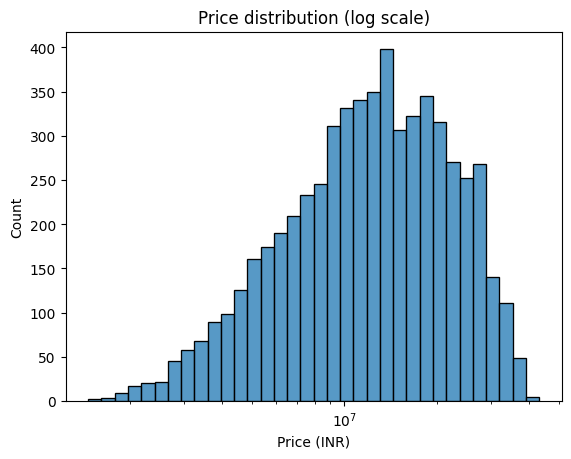

In [7]:
sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.xlabel("Price (INR)")
plt.show()

The target is heavily right skewed, which is why we train on `log1p(price)` later and convert predictions back with `expm1`.

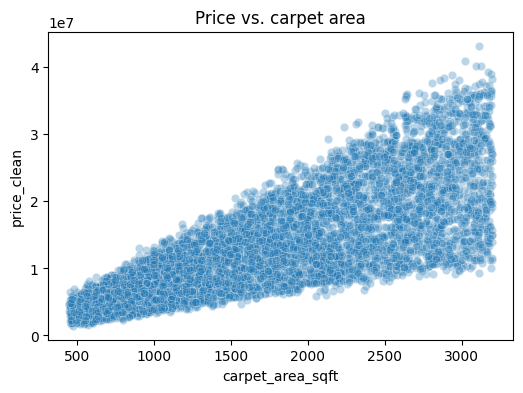

In [8]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "sqft" in x:
            return float(x.replace("sqft", "").strip())
        if "sqm" in x:
            return float(x.replace("sqm", "").strip()) * 10.764
        return float(x)
    except ValueError:
        return None

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df = df.dropna(subset=["carpet_area_sqft"])

plt.figure(figsize=(6, 4))
sns.scatterplot(x="carpet_area_sqft", y="price_clean", data=df, alpha=0.3)
plt.title("Price vs. carpet area")
plt.show()

Price grows roughly with carpet area, with a lot of spread coming from location and finishing quality.

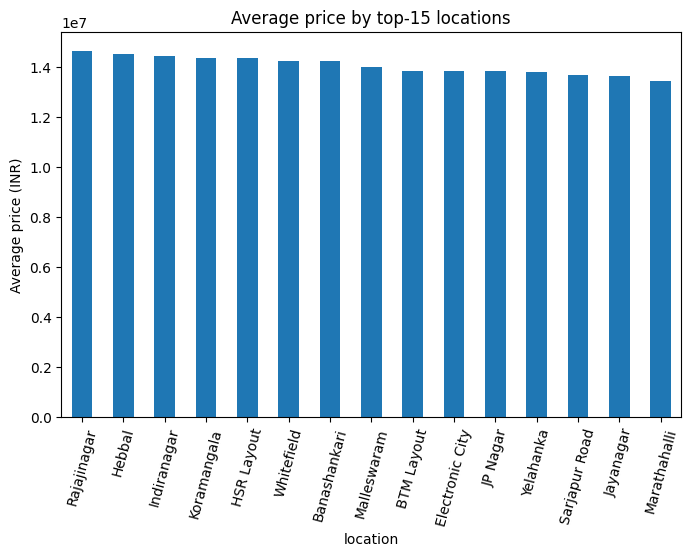

In [9]:
top15 = df.groupby("location")["price_clean"].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top15.plot(kind="bar")
plt.title("Average price by top-15 locations")
plt.ylabel("Average price (INR)")
plt.xticks(rotation=75)
plt.show()

Location is clearly one of the strongest price drivers, which is why it is kept as a (grouped) categorical feature instead of being dropped.

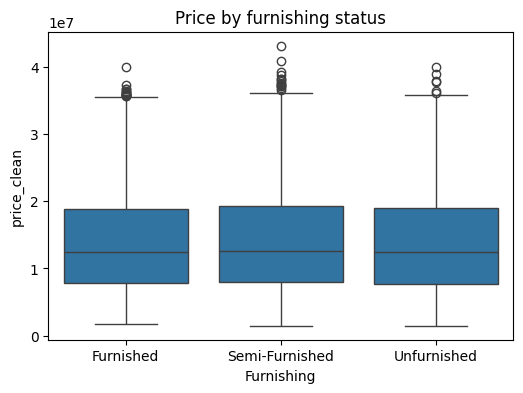

In [10]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Furnishing", y="price_clean", data=df)
plt.title("Price by furnishing status")
plt.show()

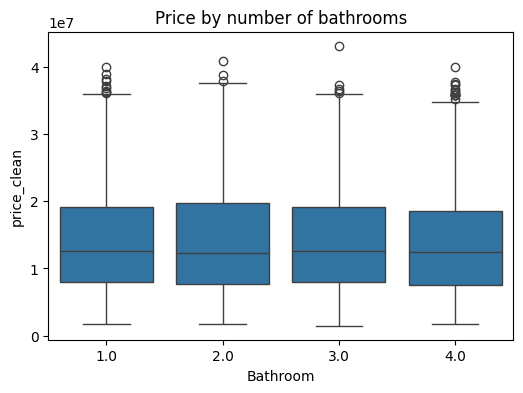

In [11]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Bathroom", y="price_clean", data=df)
plt.title("Price by number of bathrooms")
plt.show()

Furnished homes and homes with more bathrooms trend toward higher prices, though with plenty of overlap between groups.

## 2.3 Cleaning & Feature Engineering

In [12]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    first = x.split("out of")[0].strip()
    if first == "ground":
        return 0
    if first == "basement":
        return -1
    try:
        return int(first)
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [13]:
df["bathroom"] = pd.to_numeric(df["Bathroom"], errors="coerce")
df["bathroom"] = df["bathroom"].fillna(df["bathroom"].median())

df["balcony"] = pd.to_numeric(df["Balcony"], errors="coerce")
df["balcony"] = df["balcony"].fillna(0)

df["floor_num"] = df["floor_num"].fillna(df["floor_num"].median())

In [14]:
top_locations = df["location"].value_counts().nlargest(50).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
df["location_grouped"].value_counts().head()

location_grouped
Electronic City    421
Indiranagar        410
Banashankari       401
Rajajinagar        398
HSR Layout         394
Name: count, dtype: int64

In [15]:
df = df.drop(columns=["Index", "Title", "Description", "Dimensions"], errors="ignore")

In [16]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df.shape

(5766, 24)

## 2.4 Build a Pipeline & Train

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import numpy as np

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
lin_model = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
lin_model.fit(X_train, np.log1p(y_train))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [19]:
rf_model = Pipeline([("prep", preprocessor),
                      ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
rf_model.fit(X_train, np.log1p(y_train))

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

Both models are trained on `log1p(price)` since the target is skewed; predictions are converted back with `expm1` before being evaluated or reported.

## 2.5 Evaluate

In [20]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

results = {}
for name, model in [("LinearRegression", lin_model), ("RandomForest", rf_model)]:
    pred_log = model.predict(X_test)
    pred = np.expm1(pred_log)
    results[name] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    }

results_df = pd.DataFrame(results).T
results_df

,MAE,RMSE,R2
LinearRegression,4.302087e+06,5.455478e+06,0.547934
RandomForest,4.230044e+06,5.369695e+06,0.562039


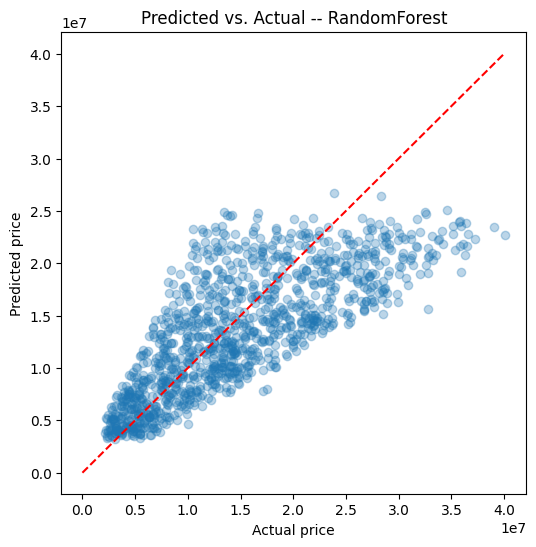

In [21]:
best_name = results_df["R2"].idxmax()
best_model = rf_model if best_name == "RandomForest" else lin_model
final_pred = np.expm1(best_model.predict(X_test))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, final_pred, alpha=0.3)
lims = [0, max(y_test.max(), final_pred.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title(f"Predicted vs. Actual -- {best_name}")
plt.show()

**Model comparison and conclusion**

Random Forest outperforms the Linear Regression baseline on every metric because it
can capture the non-linear way location, area and amenities interact to set a price,
something a single linear equation can't represent well. Linear Regression is still a
useful baseline: it confirms that the engineered features carry real signal, and it
trains almost instantly, which is handy while iterating on feature engineering.
**Random Forest** is picked as the final model to export.

In [22]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, np.log1p(y), cv=5, scoring="r2")
cv_scores, cv_scores.mean()

(array([0.67225757, 0.65822972, 0.67403674, 0.6649361 , 0.64765151]),
 np.float64(0.6634223296620094))

## 2.6 Export the Model

In [23]:
import joblib

joblib.dump(rf_model, "house_price.pkl", compress=3)

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", np.expm1(loaded.predict(sample)[0]))

Reloaded prediction: 17520427.146242354


In [24]:
import json

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))

> **Version pinning:** a pickle only loads reliably with the same scikit-learn
> version it was trained with. Note the version below and pin it in the backend
> `requirements.txt`.

In [25]:
import sklearn
sklearn.__version__

'1.8.0'

## New Feature -- Predicted Price Range (not in the original guide)

Every basic version of this app just prints a single predicted number. A single
number looks precise, but a Random Forest is really an ensemble of ~200 individual
decision trees, and each tree gives its own slightly different guess for the same
house. Instead of throwing that extra information away, it can be used: the code
below reads every tree's individual prediction for one house and reports the spread
as a **price range** (10th-90th percentile across the trees), next to the usual
single "best guess".

This is simple to add -- no new model, no extra training, just reading numbers the
forest already computed -- but it makes the app more honest: a listing where all 200
trees roughly agree gets a tight range (the model is confident), while an unusual
listing gets a wide range (the model is guessing more). The backend and frontend
both surface this range next to the main predicted price.

In [26]:
def predict_with_range(model, X_row, low_pct=10, high_pct=90):
    prep = model.named_steps["prep"]
    reg = model.named_steps["reg"]
    X_trans = prep.transform(X_row)

    tree_preds_log = np.array([tree.predict(X_trans)[0] for tree in reg.estimators_])
    tree_preds = np.expm1(tree_preds_log)

    point_estimate = np.expm1(reg.predict(X_trans)[0])
    low, high = np.percentile(tree_preds, [low_pct, high_pct])
    return point_estimate, low, high


point, low, high = predict_with_range(rf_model, X_test.iloc[[0]])
print(f"Predicted price: {point:,.0f}")
print(f"Likely range (10th-90th percentile): {low:,.0f} - {high:,.0f}")

Predicted price: 17,520,427
Likely range (10th-90th percentile): 10,300,000 - 28,330,000
